# 第 7 章 資產配置：HRP 與 Walk forward 回測

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/7-2_hrp_walk_forward.ipynb)

**對應影片**：第 7 章 單元 7-1【資產分配】風險報酬模型、7-2【資產分配】Hierarchical Risk Parity 程式撰寫、7-3【資產分配】Walk forward 資產配置回測！

**和影片的差異**

- 本單元不需要 finlab_crypto，只安裝 yfinance、PyPortfolioOpt、ffn。PyPortfolioOpt 1.6 還不支援 scipy 1.18，所以安裝時固定 `scipy<1.18`（Colab 內建的版本本來就符合）。
- 下載改用一次 `yf.download(...)` 取得所有標的，不必逐一下載再 `sleep`。
- PyPortfolioOpt 新版參數名稱是 `HRPOpt(returns=None, cov_matrix=cov)`，和影片的位置參數寫法結果相同。
- `Series.append` 已從 pandas 移除，回測結果改用 `pd.concat` 合併。

In [1]:
%pip install -q yfinance PyPortfolioOpt ffn "scipy<1.18"

Note: you may need to restart the kernel to use updated packages.


# 下載歷史資料

[yfinance](https://pypi.org/project/yfinance/) 從 Yahoo Finance 下載：台股加權指數、美國長天期公債 ETF、那斯達克指數、BTC、ETH。

<Axes: xlabel='Date'>

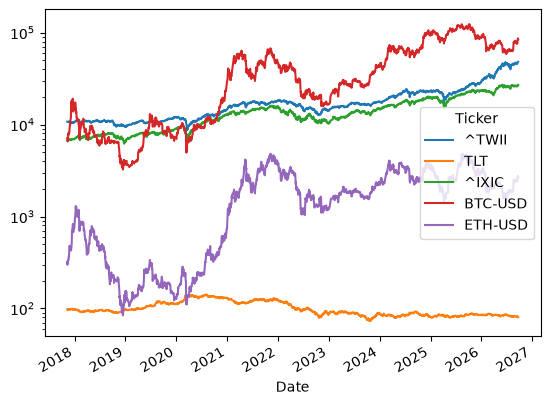

In [2]:
import yfinance as yf

symbols = ['^TWII', 'TLT', '^IXIC', 'BTC-USD', 'ETH-USD']

price = yf.download(symbols, period='max', auto_adjust=True, progress=False)['Close'][symbols]
# 只保留所有標的都有價格的日子（加密貨幣週末也交易，股市不交易）
price = price.dropna(how='any')
price.plot(logy=True)

# 7-2 Hierarchical Risk Parity

[PyPortfolioOpt 文件](https://pyportfolioopt.readthedocs.io/)、
[共變異數 cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html)

影片最後把預期報酬設為 `None`：用過去報酬預測未來報酬太粗糙，HRP 只需要共變異數。

In [3]:
from pypfopt.hierarchical_portfolio import HRPOpt

ret = price.pct_change().dropna()
portopt = HRPOpt(returns=None, cov_matrix=ret.cov())
weights = portopt.optimize()
weights

OrderedDict([('BTC-USD', np.float64(0.010691644307112802)),
             ('ETH-USD', np.float64(0.006454066499308622)),
             ('TLT', np.float64(0.511825702490184)),
             ('^IXIC', np.float64(0.1525105713075368)),
             ('^TWII', np.float64(0.3185180153958578))])

# 7-3 Walk forward 資產配置回測

每 20 個交易日：

1. 用上一段期間（`sdate` ~ `edate`）的價格估計共變異數，算出 HRP 權重
2. 用這組權重持有下一段期間（`edate` ~ `fdate`），記錄報酬

[zip](https://docs.python.org/3/library/functions.html#zip) 同時走訪三個錯開的日期序列；
[ffn 的 rebase](https://pmorissette.github.io/ffn/) 把價格換算成從 100 開始。
共變異數用 Ledoit-Wolf 收縮估計（[Honey, I Shrunk the Sample Covariance Matrix](http://www.ledoit.net/honey.pdf)），
比一般共變異數更不受雜訊影響。

,BTC-USD,ETH-USD,TLT,^IXIC,^TWII
2017-12-08,0.043772,0.055495,0.300754,0.306413,0.293567
2018-01-09,0.032142,0.019873,0.315745,0.307069,0.325171
2018-02-07,0.028144,0.024222,0.378268,0.263454,0.305911
2018-03-16,0.024387,0.040430,0.369013,0.269283,0.296886
2018-04-19,0.044235,0.029449,0.367301,0.214480,0.344535
...,...,...,...,...,...
2026-04-22,0.053362,0.029395,0.538814,0.181227,0.197202
2026-05-21,0.069662,0.065828,0.470210,0.233966,0.160334
2026-06-22,0.051986,0.026637,0.539422,0.178800,0.203156
2026-07-22,0.119557,0.053814,0.564788,0.193414,0.068427


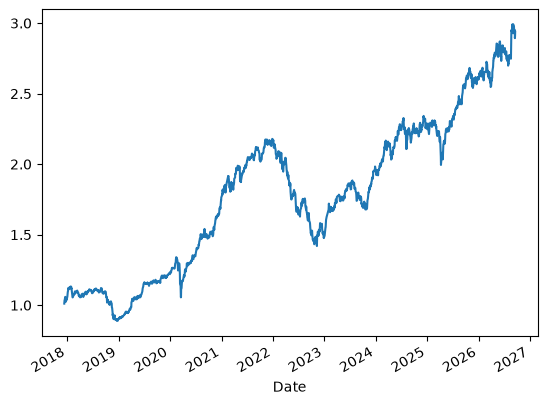

In [4]:
import ffn  # 匯入後 DataFrame 多了 rebase() 等函式
import pandas as pd
import pypfopt

REBALANCE_DAYS = 20
selected_symbols = ['^TWII', 'TLT', '^IXIC', 'BTC-USD', 'ETH-USD']
dates = price.index[::REBALANCE_DAYS]

period_returns = []
weight_history = {}

for sdate, edate, fdate in zip(dates, dates[1:], dates[2:]):
    historical_price = price.loc[sdate:edate, selected_symbols]
    cov = pypfopt.risk_models.risk_matrix(historical_price, method='ledoit_wolf')
    weights = pd.Series(HRPOpt(returns=None, cov_matrix=cov).optimize())
    weight_history[edate] = weights

    holding = (price.loc[edate:fdate, selected_symbols].rebase() * weights).sum(axis=1)
    period_returns.append(holding.pct_change().dropna())

eqs = pd.concat(period_returns)
weight_history = pd.DataFrame(weight_history).T

s = (eqs + 1).cumprod()
s.plot()
weight_history

## 最大回檔

[cummax](https://pandas.pydata.org/docs/reference/api/pandas.Series.cummax.html)：到目前為止的最高點。

<Axes: xlabel='Date'>

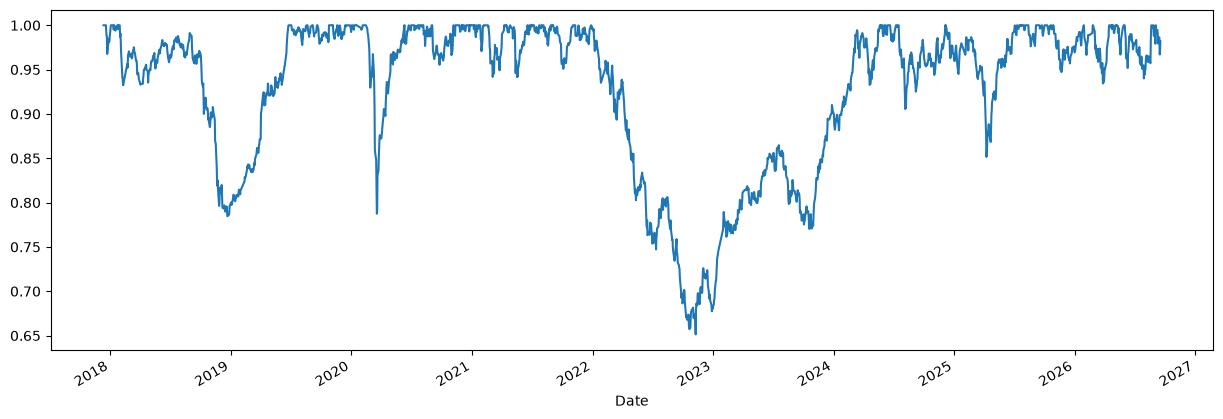

In [5]:
(s / s.cummax()).plot(figsize=(15, 5))

# 權重變化

<Axes: >

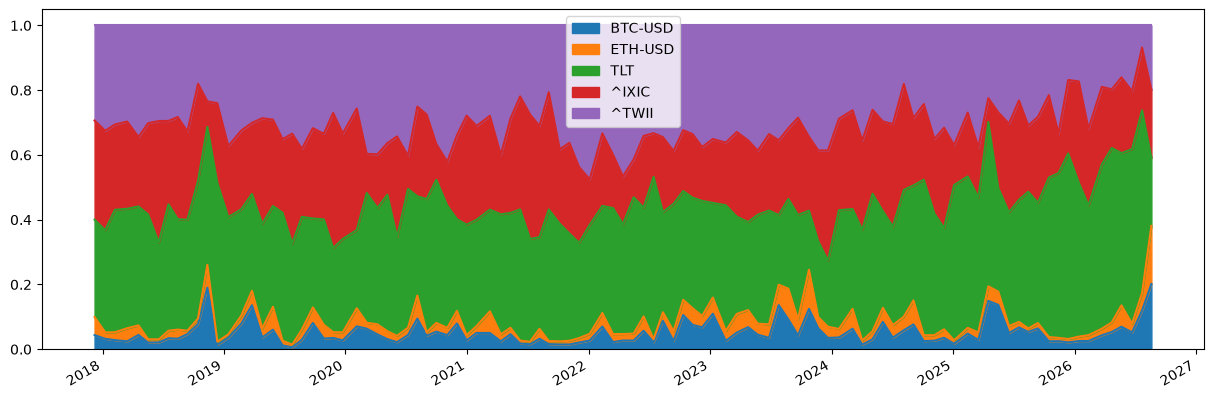

In [6]:
weight_history.plot.area(figsize=(15, 5))

## 最近 20 天算出的權重

In [7]:
historical_price = price.iloc[-REBALANCE_DAYS:]
cov = pypfopt.risk_models.risk_matrix(historical_price, method='ledoit_wolf')
HRPOpt(returns=None, cov_matrix=cov).optimize()

OrderedDict([('BTC-USD', np.float64(0.019459034899391044)),
             ('ETH-USD', np.float64(0.01721354625978939)),
             ('TLT', np.float64(0.4898898842400938)),
             ('^IXIC', np.float64(0.19691140064825102)),
             ('^TWII', np.float64(0.2765261339524748))])